In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models

from tqdm import tqdm

import utils

## Load metadata

In [2]:
AUDIO_DIR = os.environ.get("AUDIO_DIR")

tracks = utils.load("data/fma_metadata/tracks.csv")

print("Audio directory:", AUDIO_DIR)
print("Tracks shape:", tracks.shape)

Audio directory: ./data/fma_small/
Tracks shape: (106574, 52)


In [3]:
small = tracks[tracks["set", "subset"] <= "small"].copy()

small = small[
    small["track", "genre_top"].notna()
]

print("Small subset shape:", small.shape)
print(small["track", "genre_top"].value_counts())

Small subset shape: (8000, 52)
(track, genre_top)
Electronic             1000
Experimental           1000
Folk                   1000
Hip-Hop                1000
Instrumental           1000
International          1000
Pop                    1000
Rock                   1000
Blues                     0
Classical                 0
Country                   0
Easy Listening            0
Jazz                      0
Old-Time / Historic       0
Soul-RnB                  0
Spoken                    0
Name: count, dtype: int64


## Convert audio to log-mel spectrograms

To reduce training time during the baseline experiment, only the first 15 seconds of each 30-second audio clip were used. This allowed faster experimentation while still preserving enough musical information for genre classification

In [5]:
def extract_log_mel(
    file_path,
    sr=22050,
    duration=15,
    n_mels=128,
    n_fft=2048,
    hop_length=512
):
    """
    Loads an audio file and converts it into a fixed-size log-mel spectrogram.
    """

    # Load audio
    audio, sr = librosa.load(
        file_path,
        sr=sr,
        mono=True,
        duration=duration
    )

    # Make sure all audio clips have the same length
    target_length = sr * duration

    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]

    # Convert waveform to mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )

    # Convert power spectrogram to decibels
    log_mel = librosa.power_to_db(mel, ref=np.max)

    return log_mel.astype(np.float32)

## Build dataset

In [8]:
X = []
y = []
splits = []
track_ids = []

failed_files = []

print("Extracting log-mel spectrograms...")

for track_id, row in tqdm(small.iterrows(), total=len(small)):
    try:
        file_path = utils.get_audio_path(AUDIO_DIR, track_id)

        if not os.path.exists(file_path):
            failed_files.append(track_id)
            continue

        spec = extract_log_mel(file_path)

        X.append(spec)
        y.append(row["track", "genre_top"])
        splits.append(row["set", "split"])
        track_ids.append(track_id)

    except Exception as e:
        failed_files.append(track_id)

X = np.array(X, dtype=np.float32)
y = np.array(y)
splits = np.array(splits)
track_ids = np.array(track_ids)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Failed files:", len(failed_files))

Extracting log-mel spectrograms...


  0%|                                             | 0/8000 [00:00<?, ?it/s]C:\fma\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 55%|██████████████████▊               | 4423/8000 [16:00<13:07,  4.54it/s]C:\Users\sepho\AppData\Local\Temp\ipykernel_23488\2033218092.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
C:\fma\venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████████████████████████████| 8000/8000 [28:27<00:00,  4.68it/s]


X shape: (7994, 128, 646)
y shape: (7994,)
Failed files: 6


Then add the CNN channel

In [10]:
X = X[..., np.newaxis]

print("CNN input shape:", X.shape)

CNN input shape: (7994, 128, 646, 1)


Label encoding

In [11]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(label_encoder.classes_)

print("Classes:", label_encoder.classes_)
print("Number of classes:", num_classes)

Classes: ['Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock']
Number of classes: 8


Split data

In [12]:
train_mask = splits == "training"
val_mask = splits == "validation"
test_mask = splits == "test"

X_train = X[train_mask]
y_train = y_encoded[train_mask]

X_val = X[val_mask]
y_val = y_encoded[val_mask]

X_test = X[test_mask]
y_test = y_encoded[test_mask]

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Training: (6394, 128, 646, 1) (6394,)
Validation: (800, 128, 646, 1) (800,)
Test: (800, 128, 646, 1) (800,)


The dataset’s predefined split was used to separate the data into training, validation, and test sets. The training set was used to update the CNN weights, the validation set was used to monitor generalisation during training, and the test set was only used for final evaluation.

Normalise the spectrogram values

CNNs train better when input values are scaled.

In [13]:
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

print("Mean:", mean)
print("Std:", std)

Mean: -43.666893
Std: 16.498564


## CNN Model

In [14]:
input_shape = X_train.shape[1:]

model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()
model.save("basic_cnn_model.keras")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)               │ (None, 128, 646, 32)  │          320 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 64, 323, 32)   │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_1 (Conv2D)             │ (None, 64, 323, 64)   │       18,496 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_1               │ (None, 32, 161, 64)   │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_2 (Conv2D)             │ (None, 32, 161, 128)  │       73,856 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_2               │ (None, 16, 80, 128)   │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ flatten (Flatten)             │ (None, 163840)        │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 128)           │   20,971,648 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout (Dropout)             │ (None, 128)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)               │ (None, 8)             │        1,032 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 21,065,352 (80.36 MB)

 Trainable params: 21,065,352 (80.36 MB)

 Non-trainable params: 0 (0.00 B)

What this model means
Conv2D
layers.Conv2D(32, (3, 3), activation="relu")

This learns small patterns in the spectrogram.

In music, these patterns may represent:

rhythm textures
frequency energy
instrument patterns
bass-heavy areas
vocal-like regions

MaxPooling2D
layers.MaxPooling2D((2, 2))

This reduces the size of the spectrogram while keeping the important features.

It makes training faster and helps the model focus on stronger patterns.

Flatten
layers.Flatten()

This converts the learned feature maps into one long vector.

Dense
layers.Dense(128, activation="relu")

This learns higher-level combinations of features.

Dropout
layers.Dropout(0.3)

This randomly turns off 30% of neurons during training to reduce overfitting.

Softmax
layers.Dense(num_classes, activation="softmax")

This outputs probabilities for each genre.

Example:

Rock: 0.65
Hip-Hop: 0.12
Electronic: 0.10
Classical: 0.03
...

The highest probability becomes the predicted genre.

## Train the model

In [15]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 491s 2s/step - accuracy: 0.2993 - loss: 1.9575 - val_accuracy: 0.3675 - val_loss: 1.6885
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 472s 2s/step - accuracy: 0.4171 - loss: 1.6086 - val_accuracy: 0.4050 - val_loss: 1.6193
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 496s 2s/step - accuracy: 0.5042 - loss: 1.4216 - val_accuracy: 0.4750 - val_loss: 1.5537
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 477s 2s/step - accuracy: 0.5705 - loss: 1.2313 - val_accuracy: 0.4363 - val_loss: 1.6036
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 482s 2s/step - accuracy: 0.6648 - loss: 0.9738 - val_accuracy: 0.4500 - val_loss: 1.7533
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 471s 2s/step - accuracy: 0.7516 - loss: 0.7218 - val_accuracy: 0.4050 - val_loss: 2.1113
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 443s 2s/step - accuracy: 0.8222 - loss: 0.5240 - val_accuracy: 0.4162 - val_loss: 2.3916
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 440s 2s/step - accuracy: 0.8791 - loss: 0.3578 - val_accu

The initial CNN was trained for 10 epochs using the Adam optimiser and sparse categorical cross-entropy loss. A batch size of 32 was selected as a reasonable default for the baseline experiment.

Accuracy graph

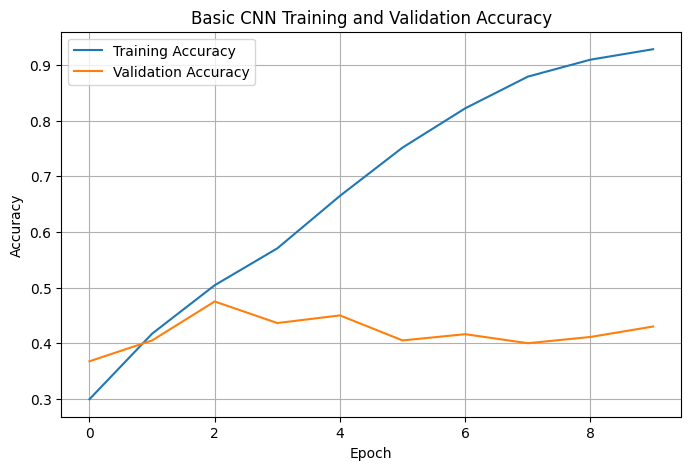

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Basic CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Loss graph

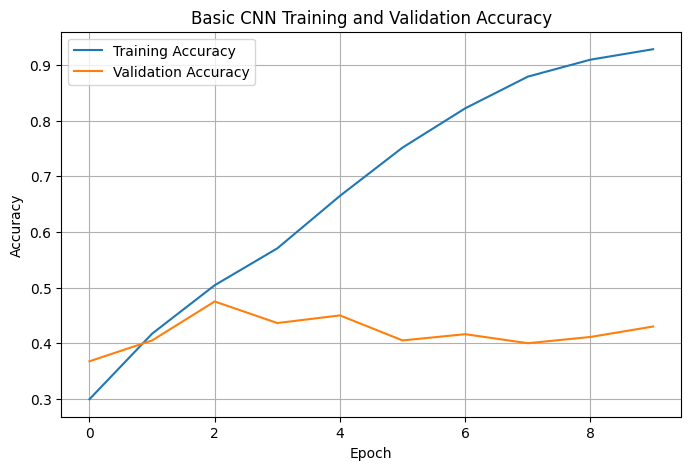

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Basic CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Evaluate on test set

In [18]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 398ms/step - accuracy: 0.3750 - loss: 3.4666
Test Loss: 3.4666476249694824
Test Accuracy: 0.375


Classifictaion Report

In [20]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 379ms/step
               precision    recall  f1-score   support

   Electronic       0.40      0.58      0.48       100
 Experimental       0.24      0.28      0.26       100
         Folk       0.18      0.17      0.17       100
      Hip-Hop       0.74      0.64      0.68       100
 Instrumental       0.33      0.29      0.31       100
International       0.45      0.47      0.46       100
          Pop       0.18      0.14      0.16       100
         Rock       0.51      0.43      0.47       100

     accuracy                           0.38       800
    macro avg       0.38      0.38      0.37       800
 weighted avg       0.38      0.38      0.37       800



Precision: how many predicted examples of a genre were correct.
Recall: how many actual examples of a genre were found.
F1-score: balance between precision and recall.
Support: number of test examples for each genre.

Confusion Matrix

<Figure size 1000x800 with 0 Axes>

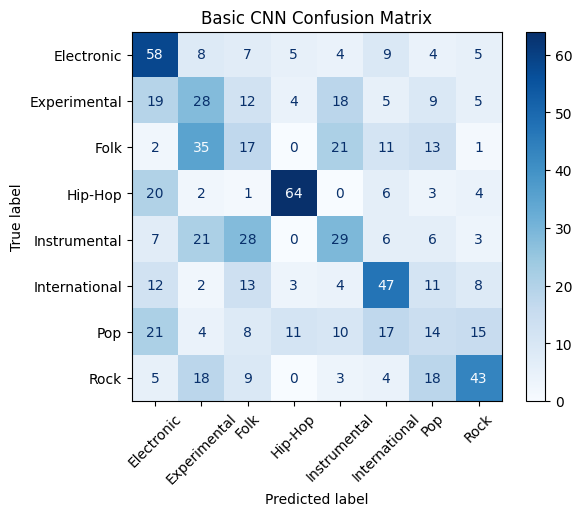

In [21]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(10, 8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Basic CNN Confusion Matrix")
plt.show()

The model implemented was a basic convolutional neural network trained on log-mel spectrograms extracted from the FMA small subset. Each audio track was loaded using Librosa and converted into a log-mel spectrogram with 128 mel frequency bands. The first 15 seconds of each 30-second track were used.

The CNN consisted of three convolutional blocks. Each block used a 2D convolutional layer with ReLU activation followed by max pooling. The convolutional layers extracted local time-frequency patterns from the spectrograms, while max pooling reduced the dimensionality of the feature maps. The extracted features were flattened and passed through a dense layer with dropout regularisation before the final softmax layer produced probabilities for the eight genre classes.

The model was trained using the Adam optimiser and sparse categorical cross-entropy loss. Training and validation accuracy/loss were recorded over 10 epochs. The final model was evaluated on the held-out test set using accuracy, precision, recall, F1-score, and a confusion matrix.

During the baseline CNN training, the training accuracy increased steadily across epochs, showing that the model was learning from the training data. However, after approximately epoch 3, validation accuracy stopped improving while training accuracy continued to rise. This suggested early signs of overfitting. As a result, early stopping was considered for later experiments to restore the best model weights based on validation loss.